# EDA — Ingeniería de datos (EPA)

Volúmenes, cobertura temporal, targets y un par de cortes demográficos/laborales. Las PNG van a `reports/memoria/eda/`.


## 1. Generar / regenerar el EDA

El script `scripts/generar_eda.py` concentra el estilo y el guardado de PNG.  
Ejecuta la celda siguiente para (re)crear todas las figuras y el resumen.

**Importante:** vuelve a ejecutar esa celda (y luego la galería) después de cambiar colores o el script. El notebook hace `importlib.reload` para no quedarse con una versión antigua en memoria.


In [1]:
import importlib
import sys
from pathlib import Path

# Raíz del repo (notebook en notebooks/ingenieria_datos/)
ROOT = Path.cwd().resolve()
if ROOT.name == "ingenieria_datos":
    ROOT = ROOT.parents[1]
elif ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import scripts.generar_eda as generar_eda

# Recarga el script siempre (si no, Jupyter guarda la versión antigua en memoria)
generar_eda = importlib.reload(generar_eda)

EDA_DIR = generar_eda.EDA_DIR
RESUMEN_JSON = generar_eda.RESUMEN_JSON
RESUMEN_MD = generar_eda.RESUMEN_MD

resumen = generar_eda.generar_eda_completo()
resumen


Cargando datasets...
  Interim: 2,627,372 | Fase1: 1,626,199 | Fase2: 1,079,939
Generando figuras...
  -> reports\memoria\eda\01_volumenes_pipeline.png
  -> reports\memoria\eda\02_cobertura_temporal.png
  -> reports\memoria\eda\03_target_fase1_macro.png
  -> reports\memoria\eda\04_edad_sexo_fase1.png
  -> reports\memoria\eda\05_educacion_vs_estado.png
  -> reports\memoria\eda\10_evolucion_estado_fase1.png
  -> reports\memoria\eda\12_top_ccaa_parado_fase1.png
  -> reports\memoria\eda\06_subempleo_fase2.png
  -> reports\memoria\eda\07_horas_vs_subempleo.png
  -> reports\memoria\eda\08_jornada_vs_subempleo.png
  -> reports\memoria\eda\11_evolucion_subempleo_fase2.png
  -> reports\memoria\eda\09_nulos_estructurales.png
  -> reports\memoria\eda\resumen_eda.md
  -> reports\memoria\eda\resumen_eda.json
EDA completado.


{'interim_filas': 2627372,
 'interim_columnas': 97,
 'fase1_filas': 1626199,
 'fase1_columnas': 26,
 'fase2_filas': 1079939,
 'fase2_columnas': 32,
 'fase1_pct_ocupado': 65.17,
 'fase1_pct_parado': 8.76,
 'fase1_pct_inactivo': 26.07,
 'fase2_tasa_subempleo': 7.59,
 'periodos': ['2021T1',
  '2021T2',
  '2021T3',
  '2021T4',
  '2022T1',
  '2022T2',
  '2022T3',
  '2022T4',
  '2023T1',
  '2023T2',
  '2023T3',
  '2023T4',
  '2024T1',
  '2024T2',
  '2024T3',
  '2024T4',
  '2025T1',
  '2025T2',
  '2025T3',
  '2025T4',
  '2026T1']}

## 2. Galería de figuras

Vista rápida de lo generado (también están en disco para la memoria).

12 figuras en reports\memoria\eda


### `01_volumenes_pipeline.png`

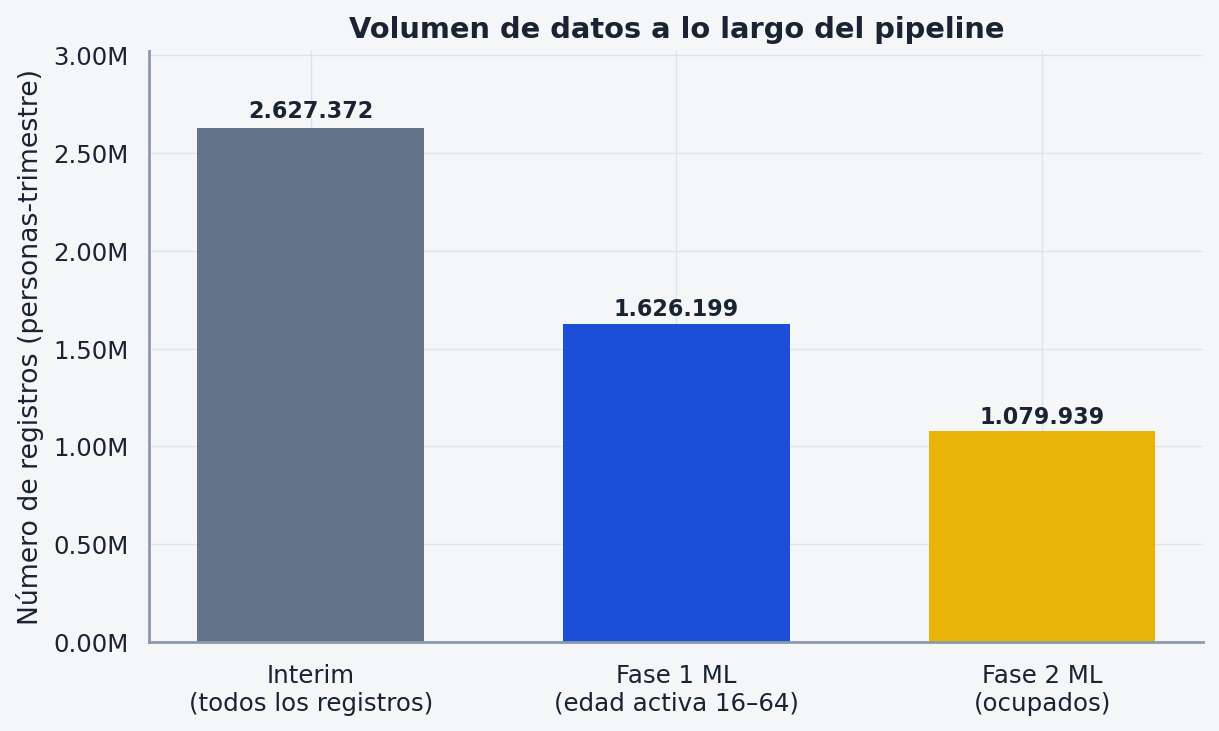

### `02_cobertura_temporal.png`

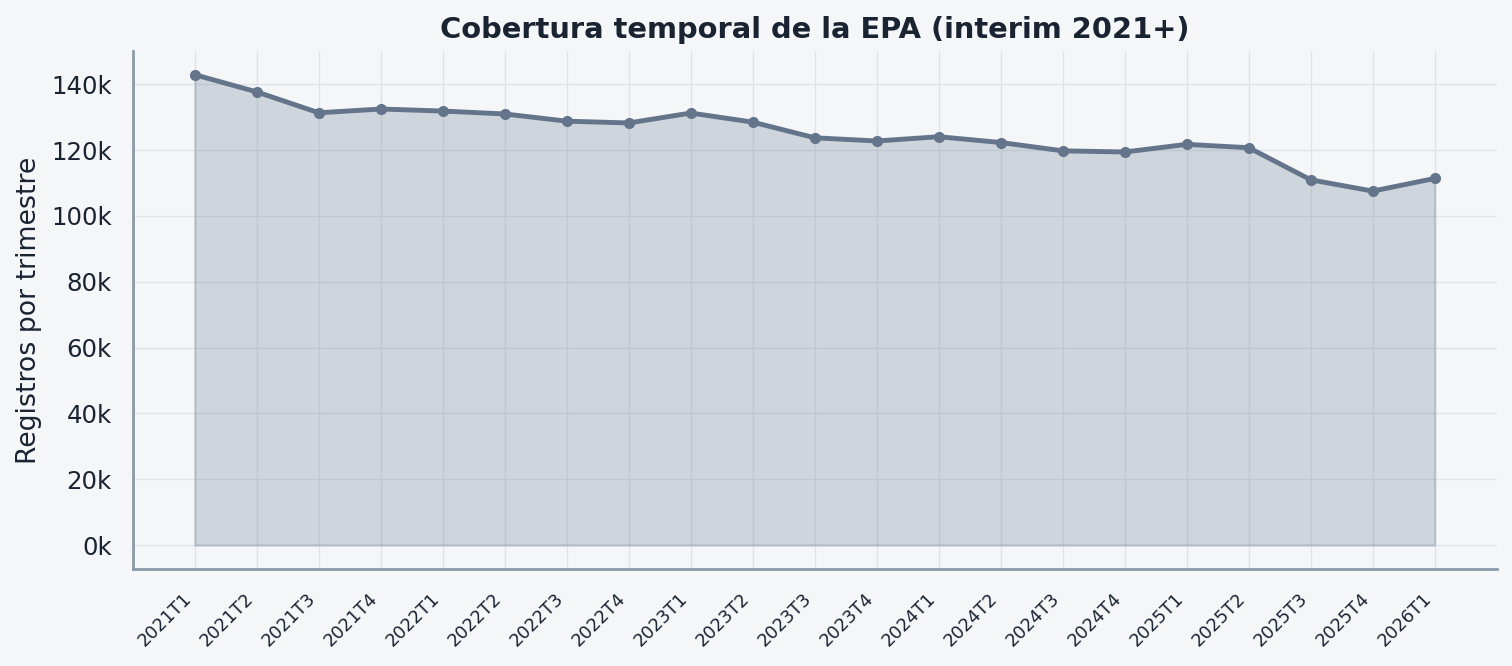

### `03_target_fase1_macro.png`

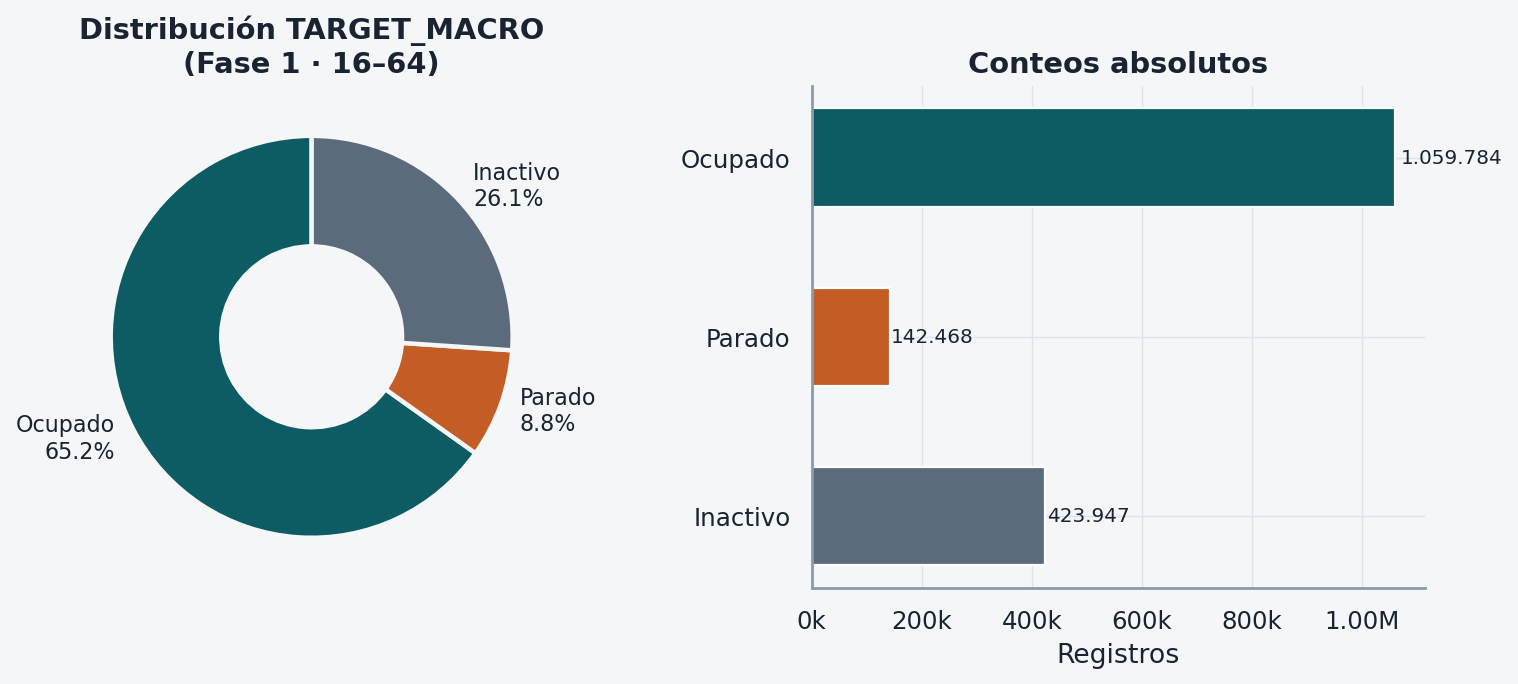

### `04_edad_sexo_fase1.png`

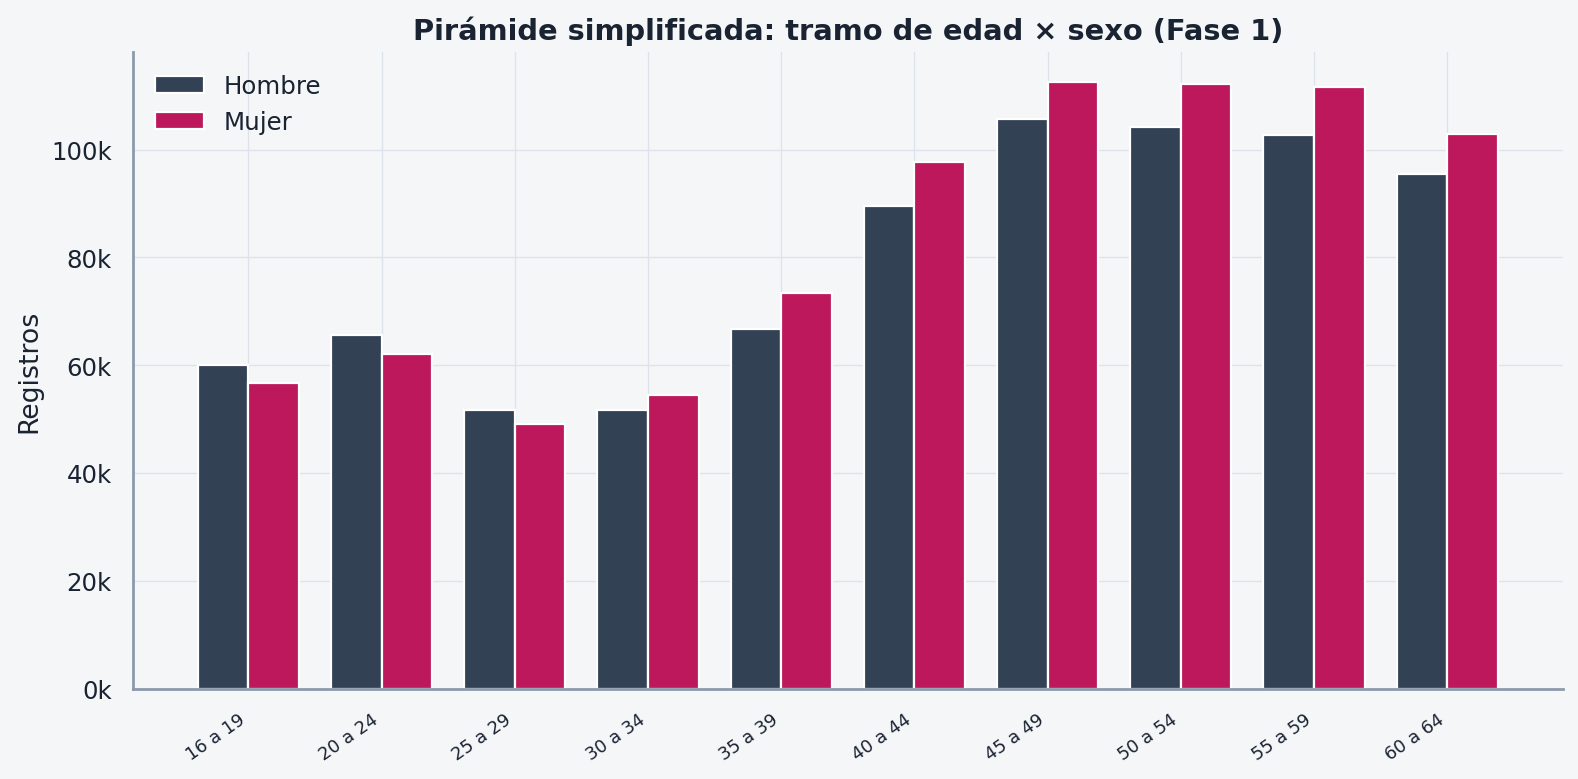

### `05_educacion_vs_estado.png`

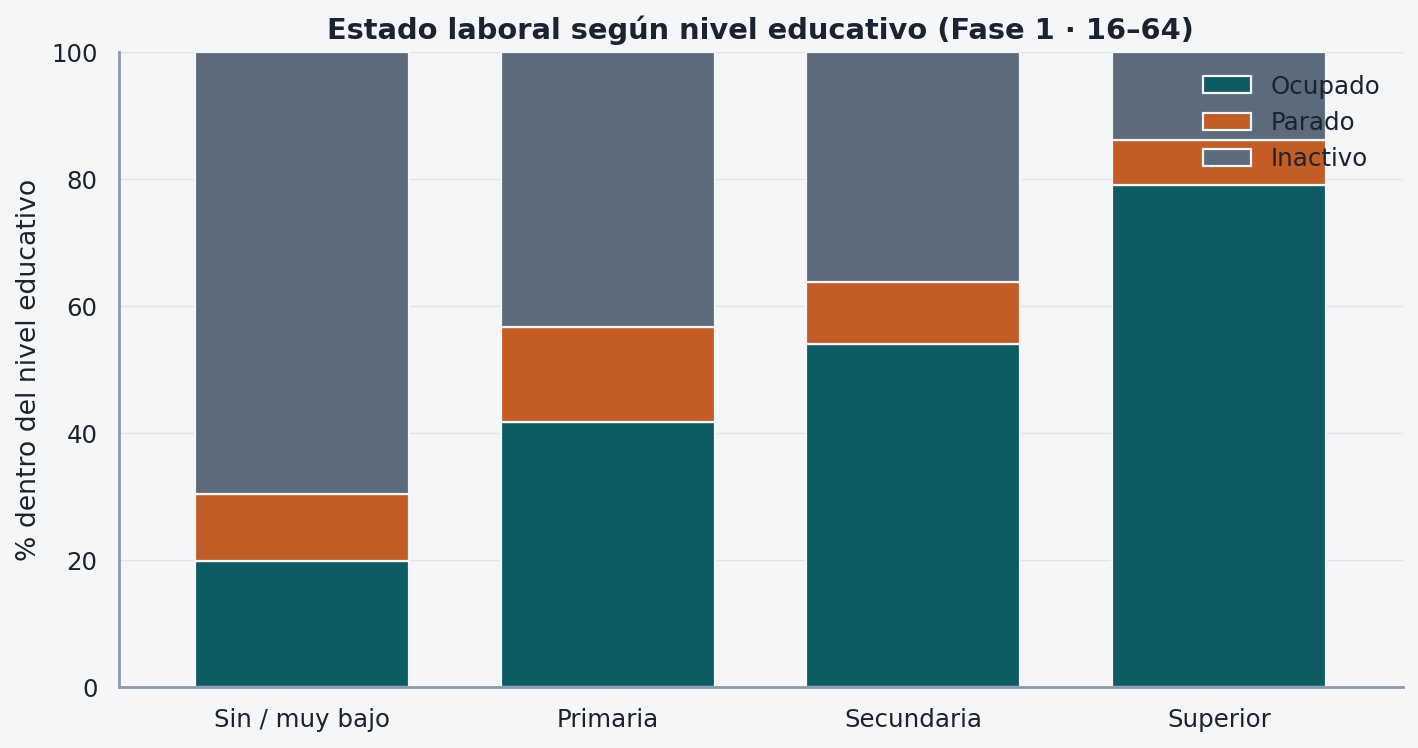

### `06_subempleo_fase2.png`

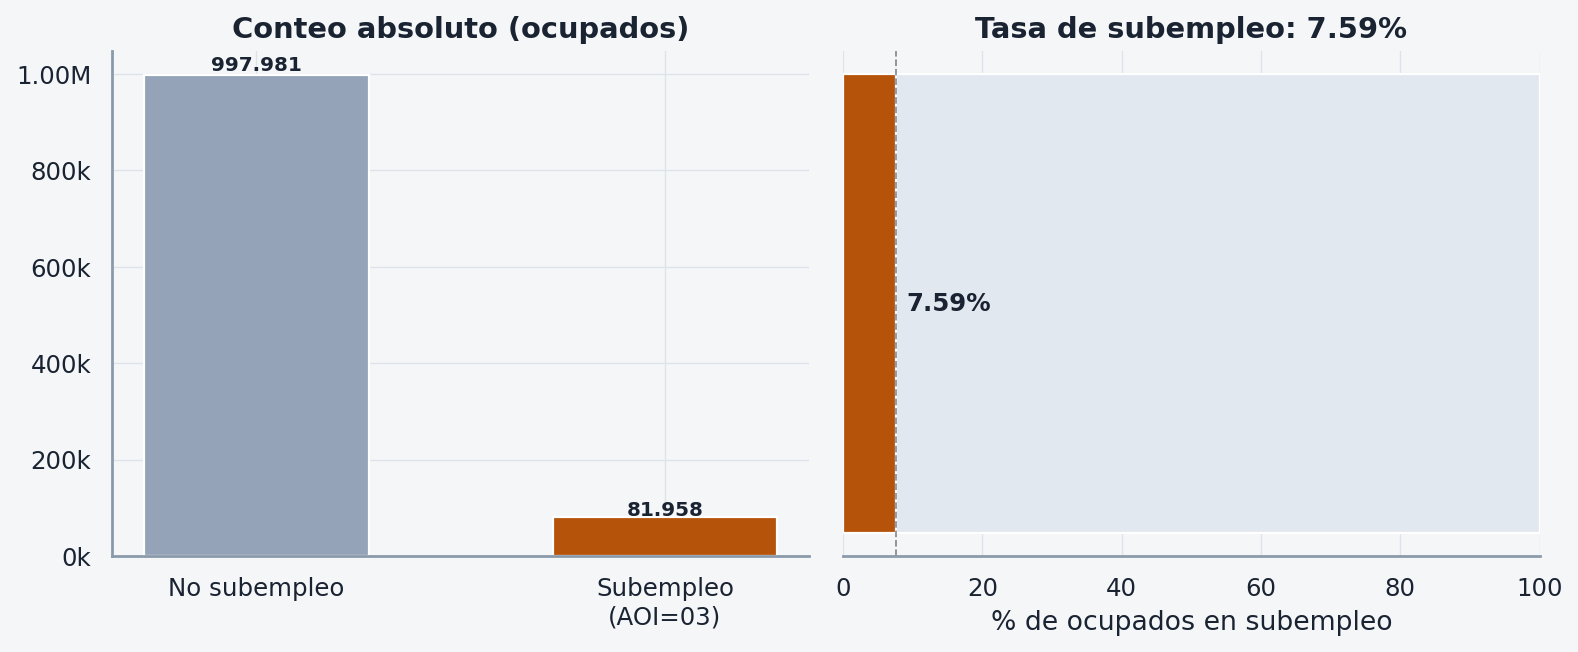

### `07_horas_vs_subempleo.png`

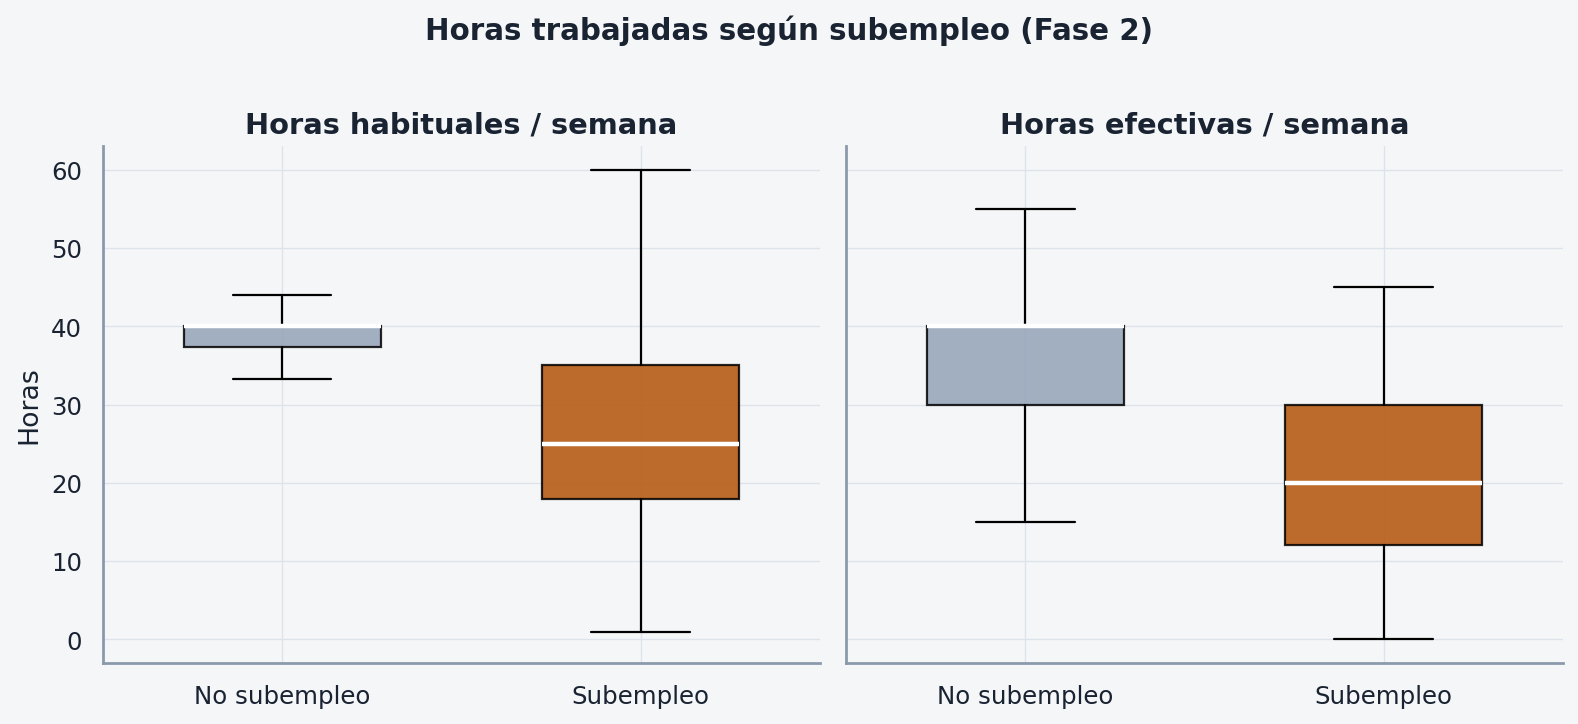

### `08_jornada_vs_subempleo.png`

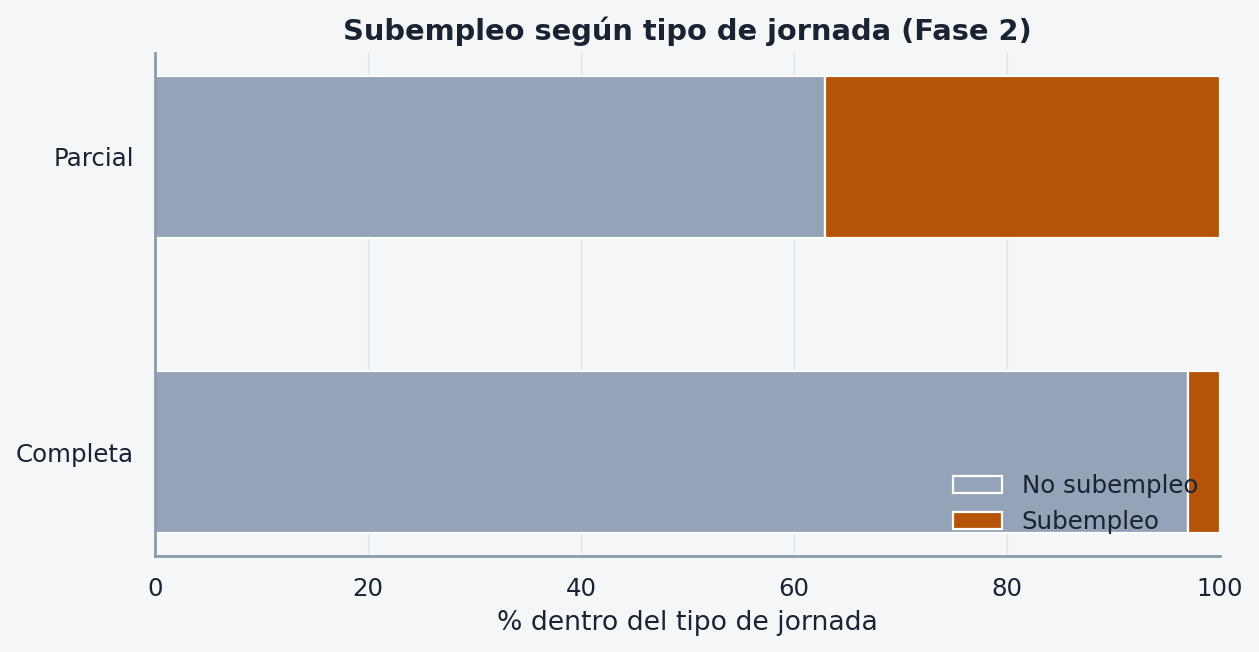

### `09_nulos_estructurales.png`

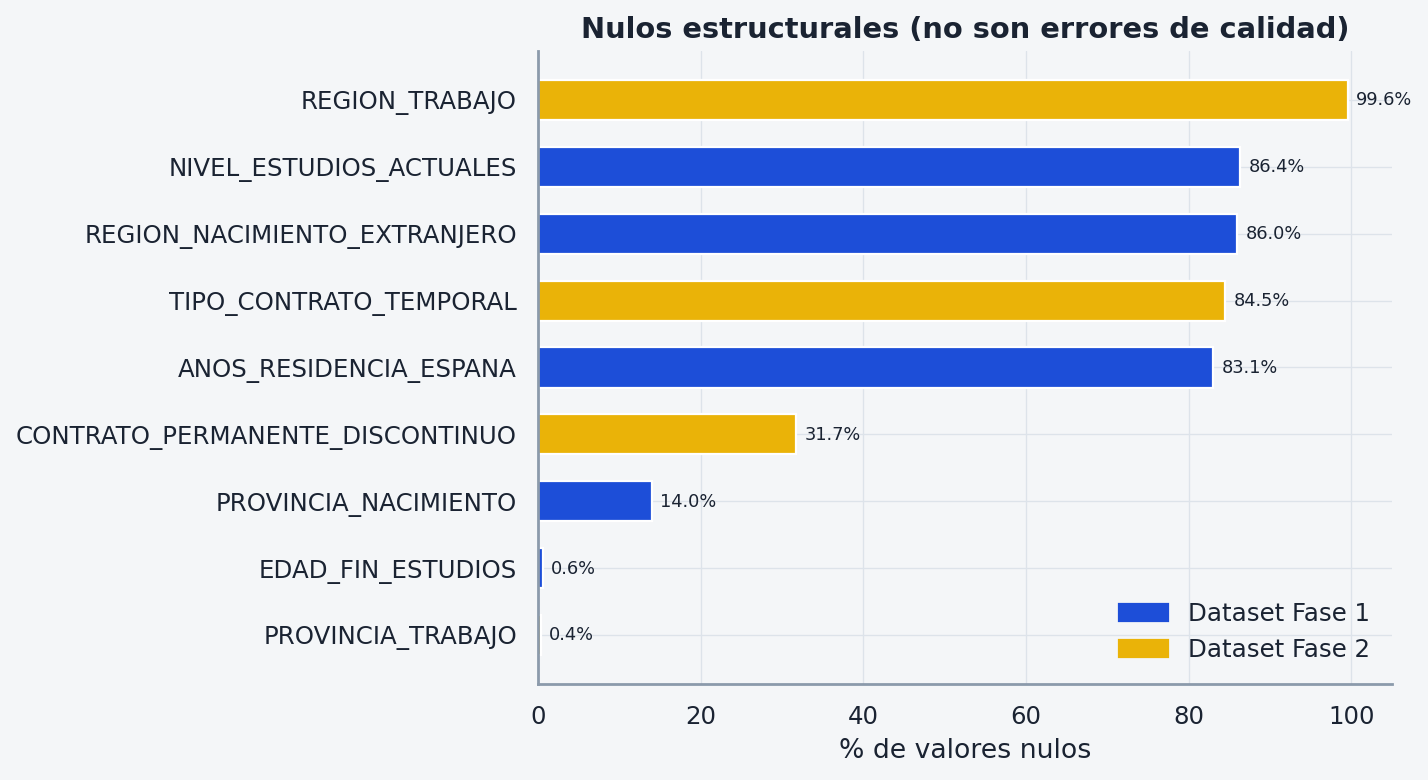

### `10_evolucion_estado_fase1.png`

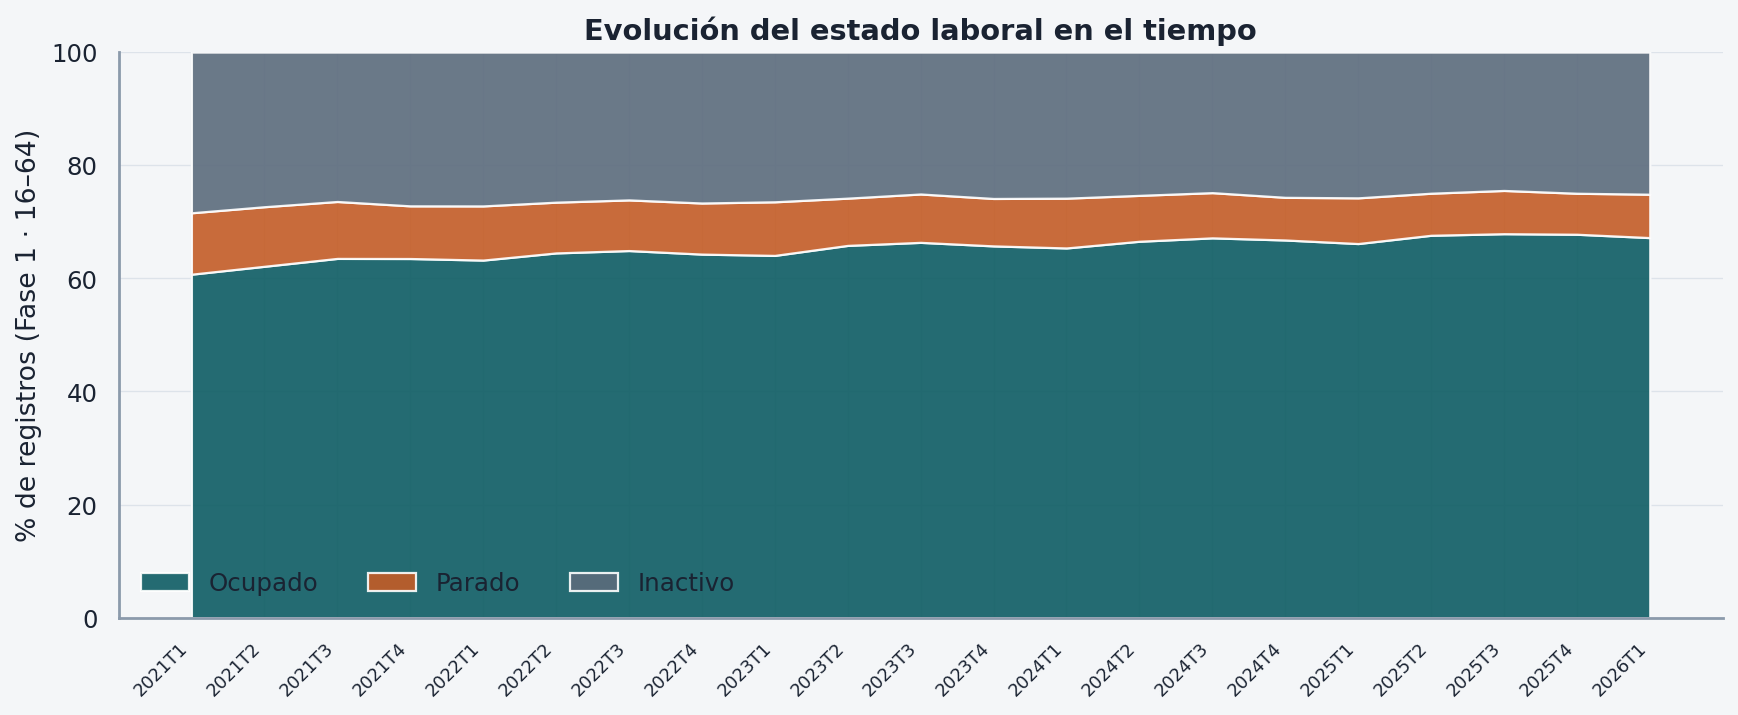

### `11_evolucion_subempleo_fase2.png`

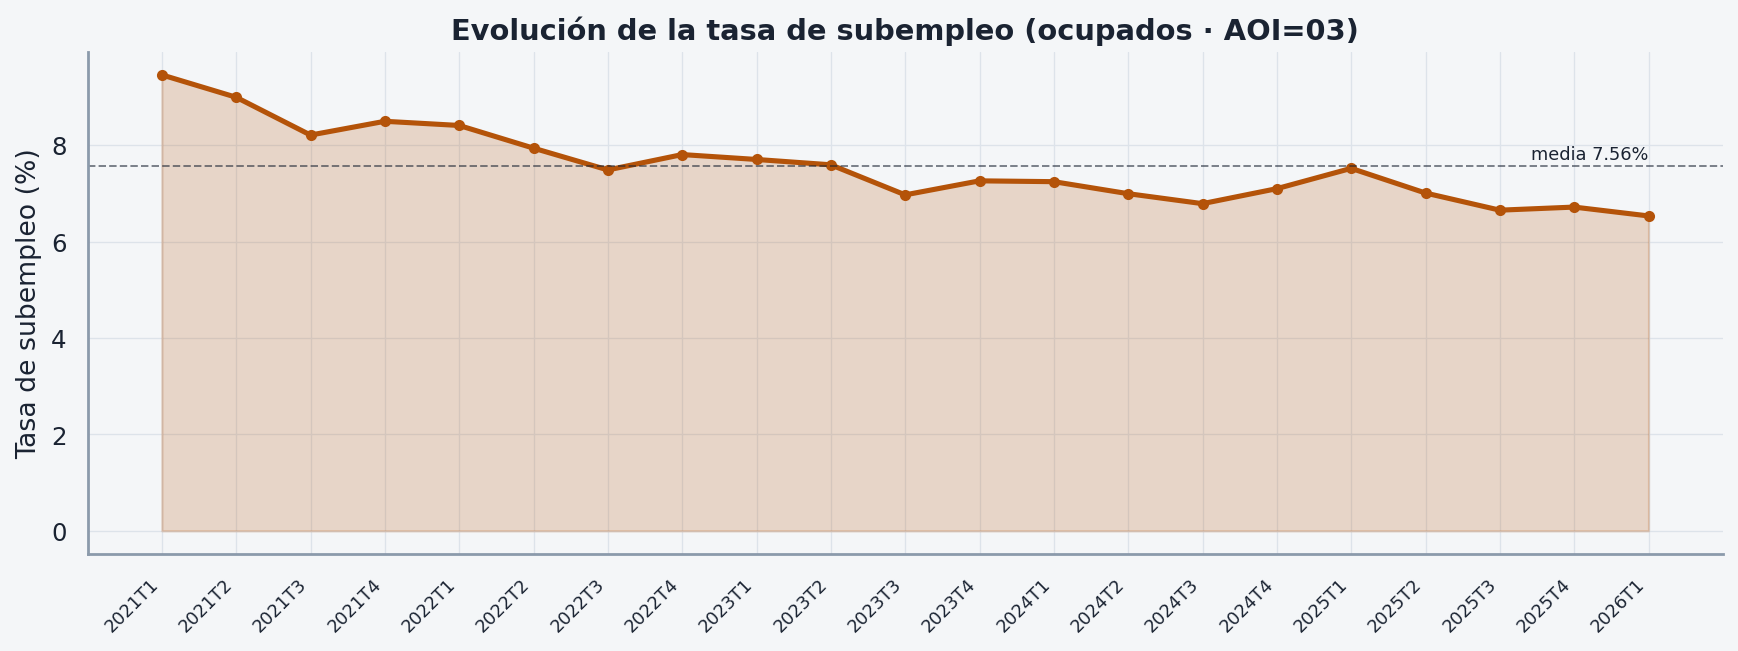

### `12_top_ccaa_parado_fase1.png`

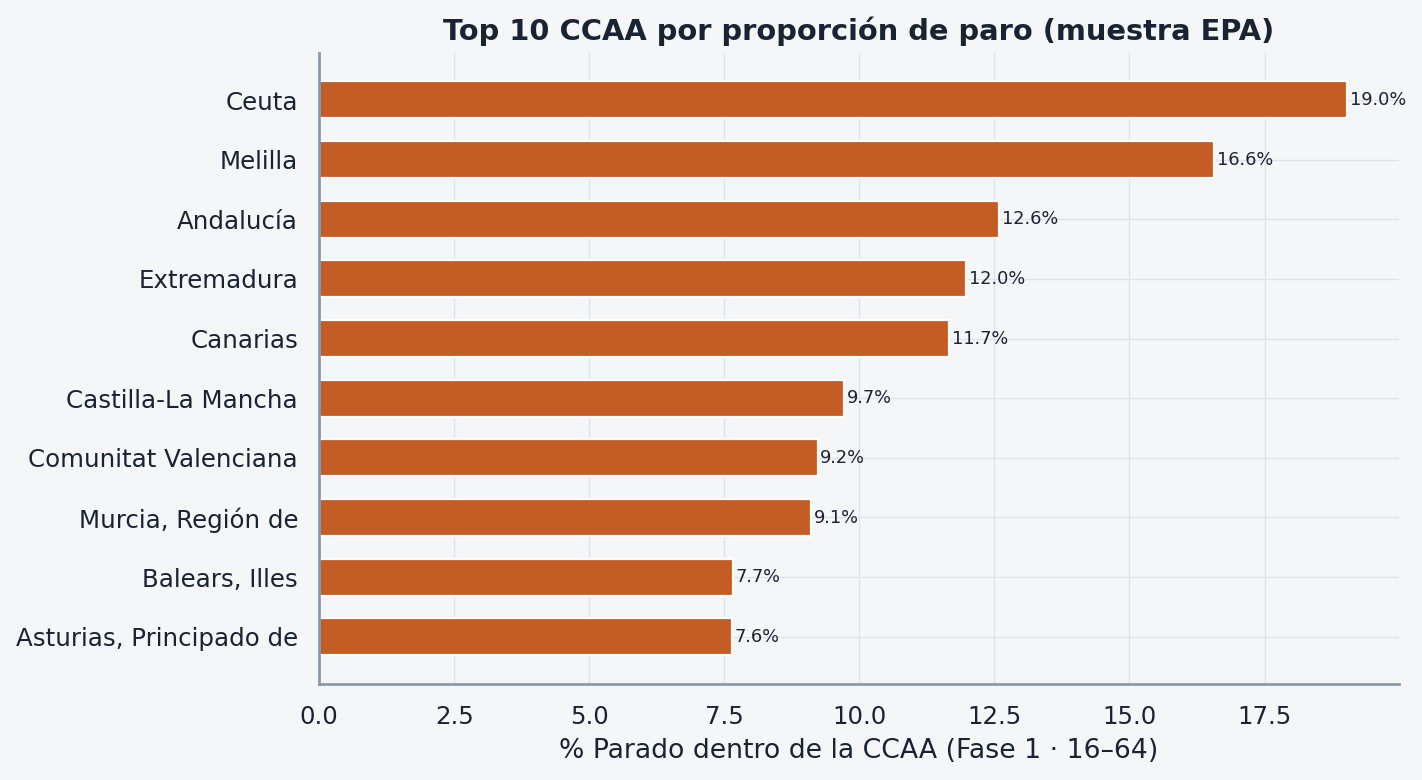

In [4]:
from IPython.display import Image, Markdown, display

figuras = sorted(EDA_DIR.glob("*.png"))
print(f"{len(figuras)} figuras en {EDA_DIR.relative_to(ROOT)}")
for fig in figuras:
    display(Markdown(f"### `{fig.name}`"))
    # Leer bytes (no filename): evita caché del visor del notebook
    display(Image(data=fig.read_bytes(), width=720))


## 3. Resumen numérico (para citar en la memoria)

In [6]:
import json

with open(RESUMEN_JSON, encoding="utf-8") as f:
    datos = json.load(f)

print("=== VOLÚMENES ===")
print(f"Interim:     {datos['interim_filas']:>12,}  ({datos['interim_columnas']} cols)")
print(f"Fase 1 16-64:{datos['fase1_filas']:>12,}  ({datos['fase1_columnas']} cols)")
print(f"Fase 2 ocup.:{datos['fase2_filas']:>12,}  ({datos['fase2_columnas']} cols)")
print()
print("=== TARGET FASE 1 ===")
print(f"Ocupado  {datos['fase1_pct_ocupado']:5.2f}%")
print(f"Parado   {datos['fase1_pct_parado']:5.2f}%")
print(f"Inactivo {datos['fase1_pct_inactivo']:5.2f}%")
print()
print("=== TARGET FASE 2 ===")
print(f"Tasa subempleo (AOI=03): {datos['fase2_tasa_subempleo']:.2f}%")
print()
print("Markdown:", RESUMEN_MD.relative_to(ROOT))

=== VOLÚMENES ===
Interim:        2,627,372  (97 cols)
Fase 1 16-64:   1,626,199  (26 cols)
Fase 2 ocup.:   1,079,939  (32 cols)

=== TARGET FASE 1 ===
Ocupado  65.17%
Parado    8.76%
Inactivo 26.07%

=== TARGET FASE 2 ===
Tasa subempleo (AOI=03): 7.59%

Markdown: reports\memoria\eda\resumen_eda.md


## 4. Decisiones que este EDA ilustra

| Decisión | Evidencia en el EDA |
|---|---|
| Filtrar **16–64** en Fase 1 | Volumen Fase 1 < interim; evita dominancia de jubilación |
| Fase 2 = solo ocupados | Target binario con ~7–8% positivos |
| Horas / jornada en Fase 2 | Boxplots y barras: separación clara subempleo vs no |
| Nulos altos en origen/contrato | Figura de nulos (azul/ámbar = dataset, no estado laboral) |
| Educación ↔ estado laboral | Stacked bar: más educación, más ocupación |
| Estabilidad temporal | Evolución trimestral estado laboral y tasa de subempleo |
| Lectura territorial | Top CCAA por % parado (muestra EPA) |

**Colores:** verde petróleo / naranja / gris = estados laborales; azul / ámbar = datasets Fase 1 / Fase 2 (no mezclar en la memoria).

Figuras del EDA listas para la memoria.
